<a href="https://colab.research.google.com/github/kyelea-boo/Bootcamp/blob/main/%5BClustering%5D_Submission_Akhir_BMLP_Susi_(Updated).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset **tanpa label** dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.
   
2. **Ketentuan Dataset**:
   - **Tanpa label**: Dataset tidak boleh memiliki label atau kelas.
   - **Jumlah Baris**: Minimal 1000 baris untuk memastikan dataset cukup besar untuk analisis yang bermakna.
   - **Tipe Data**: Harus mengandung data **kategorikal** dan **numerikal**.
     - *Kategorikal*: Misalnya jenis kelamin, kategori produk.
     - *Numerikal*: Misalnya usia, pendapatan, harga.

3. **Pembatasan**:  
   Dataset yang sudah digunakan dalam latihan clustering (seperti customer segmentation) tidak boleh digunakan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from scipy import stats
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

In [ ]:
df = pd.read_csv('/content/synthetic_beverage_sales_data1.csv')
df.head()

,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_ID.1
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,ORD1
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,ORD1
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,ORD1
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,ORD1
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,ORD1


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset. EDA bertujuan untuk:

1. **Memahami Struktur Data**
   - Tinjau jumlah baris dan kolom dalam dataset.  
   - Tinjau jenis data di setiap kolom (numerikal atau kategorikal).

2. **Menangani Data yang Hilang**  
   - Identifikasi dan analisis data yang hilang (*missing values*). Tentukan langkah-langkah yang diperlukan untuk menangani data yang hilang, seperti pengisian atau penghapusan data tersebut.

3. **Analisis Distribusi dan Korelasi**  
   - Analisis distribusi variabel numerik dengan statistik deskriptif dan visualisasi seperti histogram atau boxplot.  
   - Periksa hubungan antara variabel menggunakan matriks korelasi atau scatter plot.

4. **Visualisasi Data**  
   - Buat visualisasi dasar seperti grafik distribusi dan diagram batang untuk variabel kategorikal.  
   - Gunakan heatmap atau pairplot untuk menganalisis korelasi antar variabel.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
df.describe()

,Unit_Price,Quantity,Discount,Total_Price
count,10000.000000,10000.00000,10000.000000,10000.000000
mean,5.766586,23.06040,0.029065,126.547736
std,14.721471,26.86648,0.044477,496.777802
min,0.320000,1.00000,0.000000,0.390000
25%,1.070000,6.00000,0.000000,8.640000
50%,1.800000,11.00000,0.000000,21.130000
75%,3.210000,29.00000,0.050000,68.322500
max,132.090000,100.00000,0.150000,10112.850000


In [ ]:
df.shape

(10000, 11)

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Customer_Type,0
Product,0
Category,0
Unit_Price,0
Quantity,0
Discount,0
Total_Price,0
Region,0


In [ ]:
df.dtypes

,0
Order_ID,object
Customer_ID,object
Customer_Type,object
Product,object
Category,object
Unit_Price,float64
Quantity,int64
Discount,float64
Total_Price,float64
Region,object


In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')

<ipython-input-8-1c76c274f4c6>:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x] , bins = 20)
<ipython-input-8-1c76c274f4c6>:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[x] , bins = 20)
<ipython-input-8-1c76c274f4c6>:8: UserWarning: 

`distplot` is a deprecated function and will be r

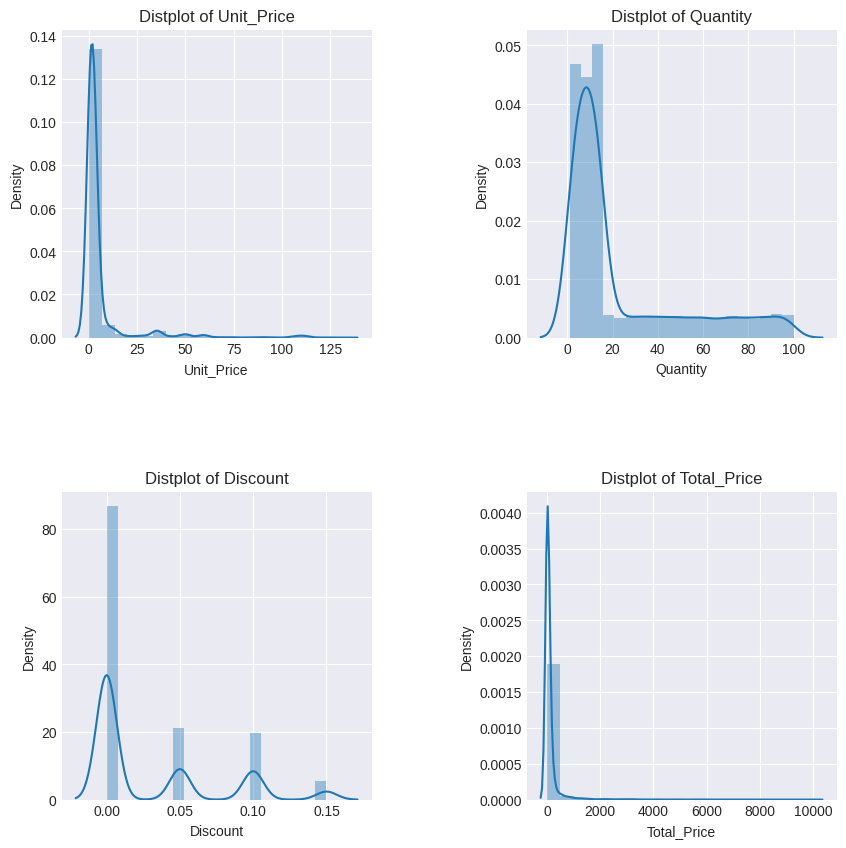

In [ ]:
plt.figure(1 , figsize = (10, 10))
num_features = df.select_dtypes(include = ['float64' , 'int64'])
n = 0
for x in num_features:
    n += 1
    plt.subplot(2, 2, n)
    plt.subplots_adjust(hspace=0.5 , wspace = 0.5)
    sns.distplot(df[x] , bins = 20)
    plt.title('Distplot of {}'.format(x))
plt.show()

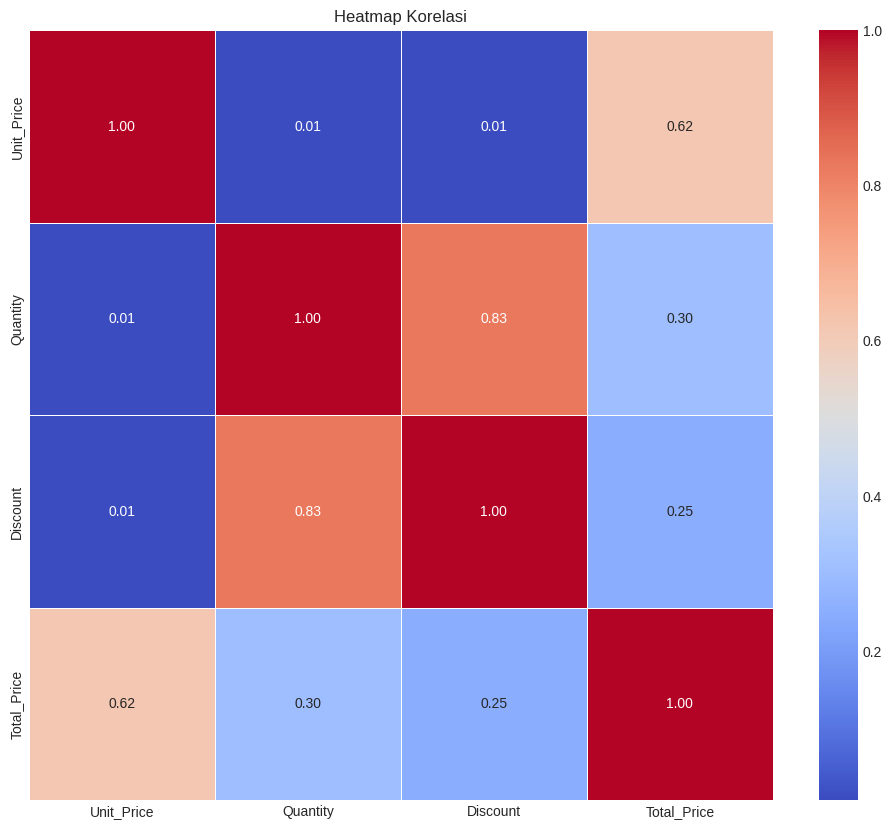

In [ ]:
plt.figure(figsize=(12, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

<ipython-input-10-4322d76cae39>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df["Category"], palette="cividis")


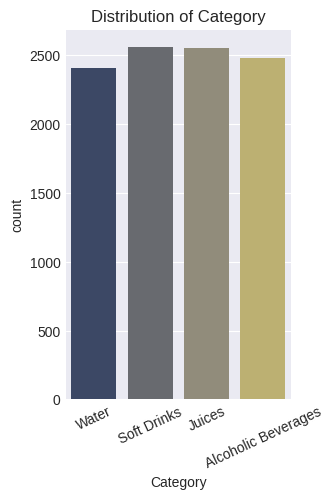

In [ ]:
# Countplot untuk Category
plt.subplot(1, 2, 1)
sns.countplot(x=df["Category"], palette="cividis")
plt.xticks(rotation=25)
plt.title("Distribution of Category")
plt.show()

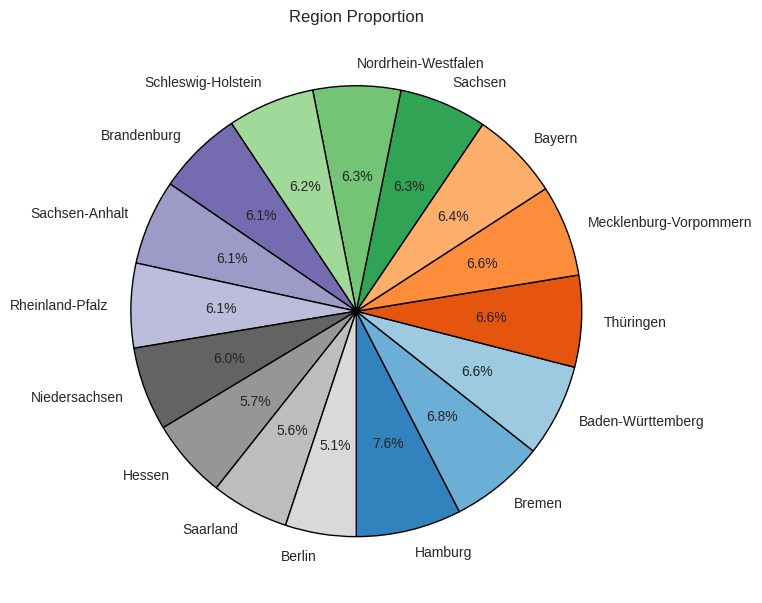

In [ ]:
# Pie Chart untuk Region
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)

df["Region"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    cmap="tab20c",
    wedgeprops={'edgecolor': 'black'},
    startangle=270
    )

plt.ylabel("")
plt.title("Region Proportion")
plt.show()

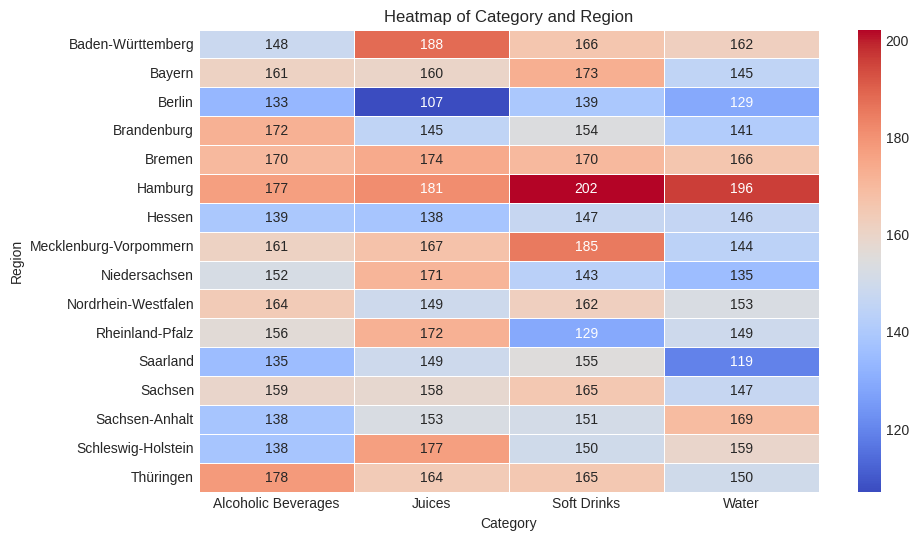

In [ ]:
heatmap_data = df.pivot_table(index="Region", columns="Category", aggfunc="size", fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", annot=True, fmt="d", linewidths=0.5)

plt.title("Heatmap of Category and Region")
plt.xlabel("Category")
plt.ylabel("Region")

plt.show()

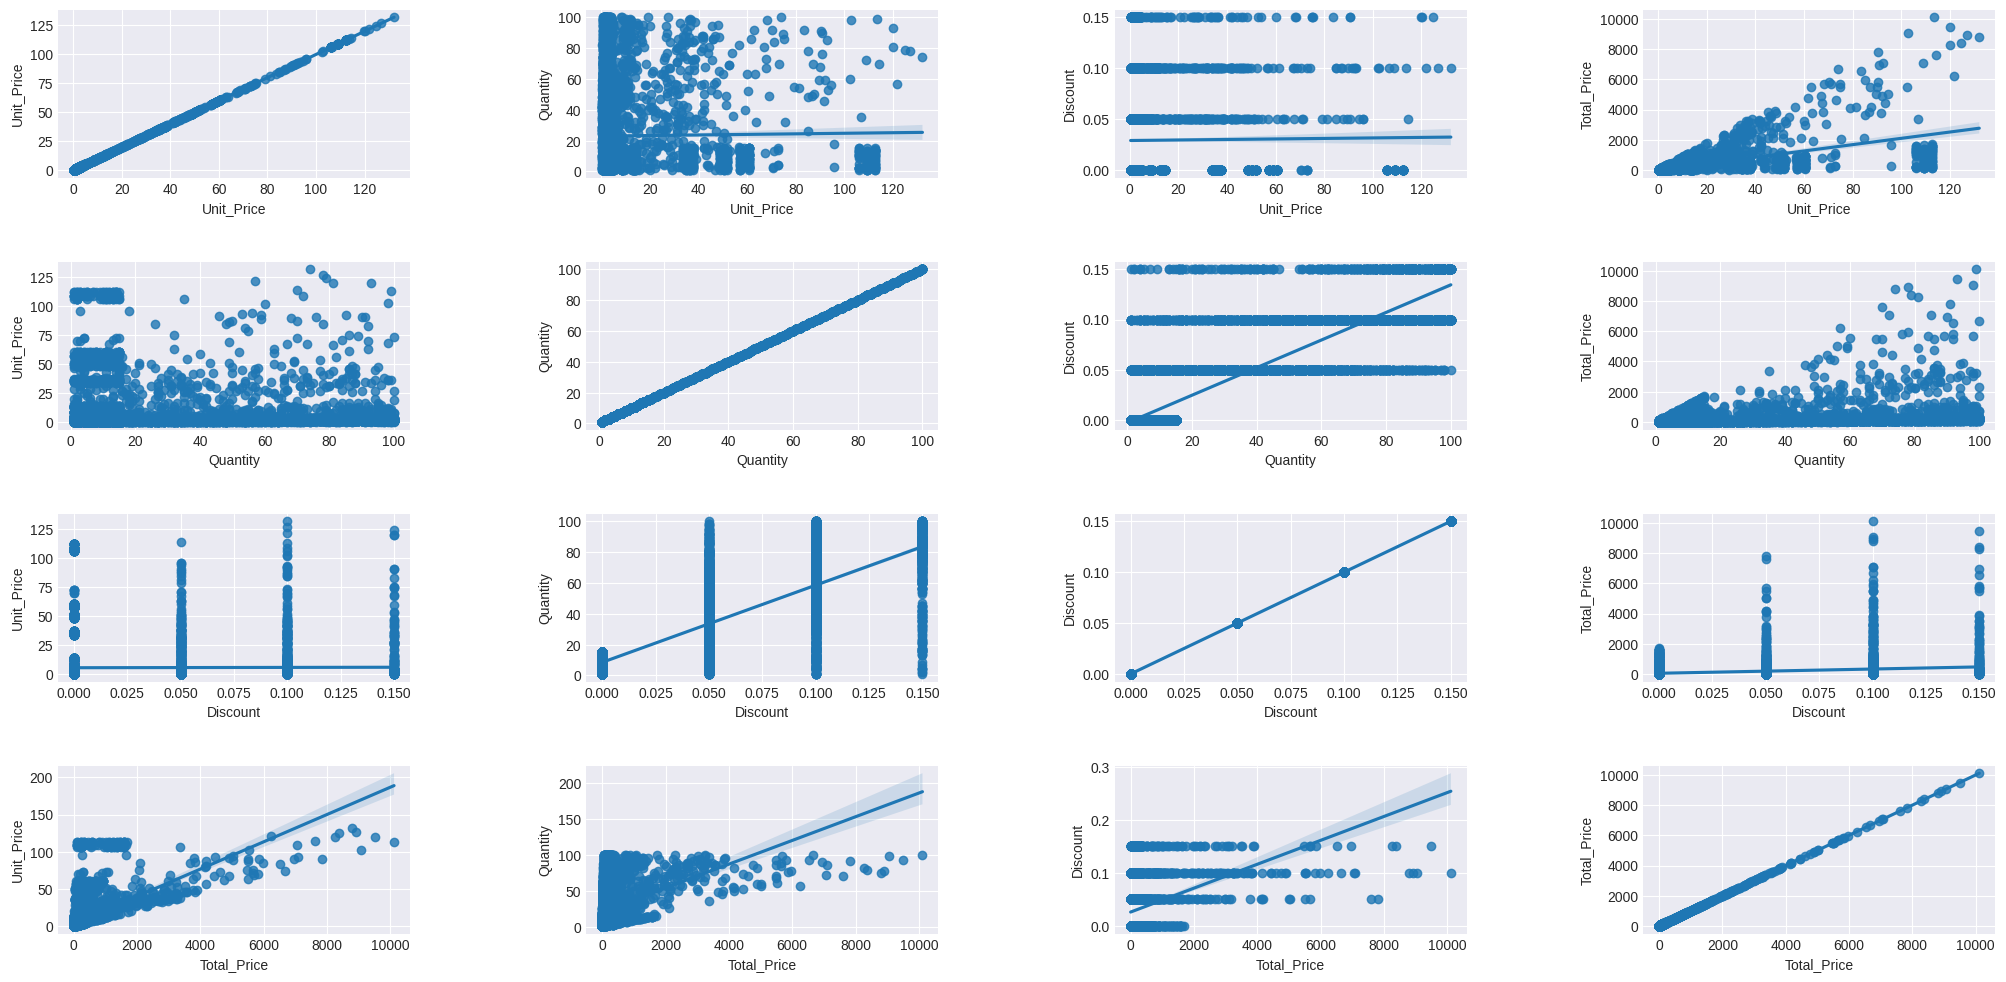

In [ ]:
plt.figure(1 , figsize = (25 , 12))

n = 0
for x in num_features:
    for y in num_features:
        n += 1
        plt.subplot(4, 4, n)
        plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
        sns.regplot(x = x , y = y , data = df)
        plt.ylabel(y.split()[0]+' '+y.split()[1] if len(y.split()) > 1 else y )
plt.show()

<ipython-input-14-507d5ef1a99a>:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="Category", y="Total_Price", hue="Region", estimator=np.mean, ci=None)


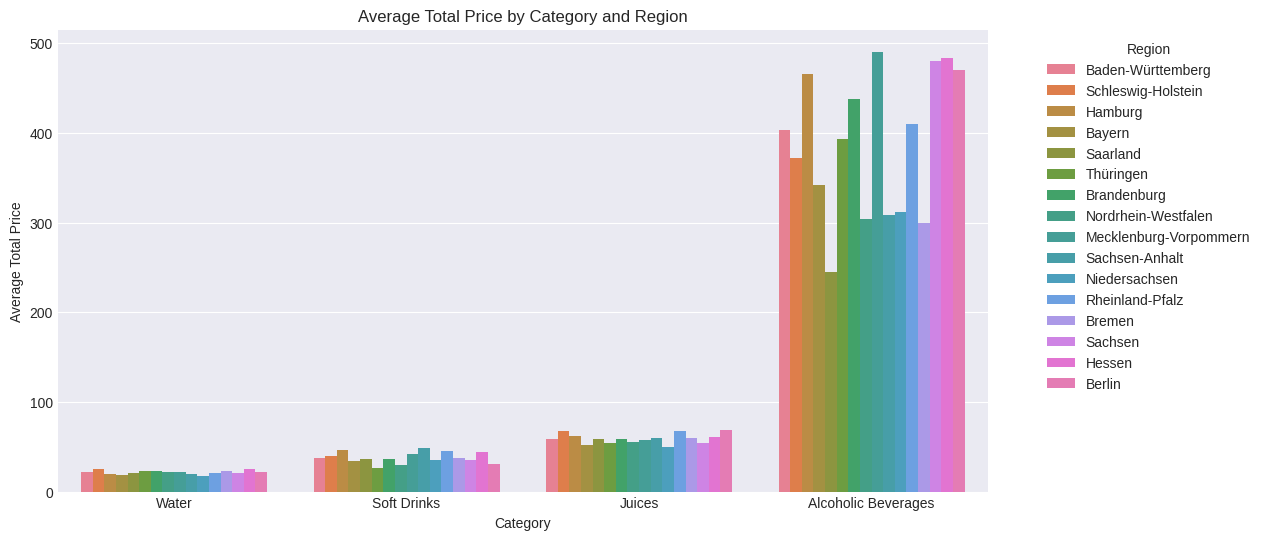

In [ ]:
# Menghubungkan antara Category, Total Price dan Region
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Category", y="Total_Price", hue="Region", estimator=np.mean, ci=None)

plt.title("Average Total Price by Category and Region")
plt.xlabel("Category")
plt.ylabel("Average Total Price")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning. Data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       10000 non-null  object 
 1   Customer_ID    10000 non-null  object 
 2   Customer_Type  10000 non-null  object 
 3   Product        10000 non-null  object 
 4   Category       10000 non-null  object 
 5   Unit_Price     10000 non-null  float64
 6   Quantity       10000 non-null  int64  
 7   Discount       10000 non-null  float64
 8   Total_Price    10000 non-null  float64
 9   Region         10000 non-null  object 
 10  Order_ID.1     10000 non-null  object 
dtypes: float64(3), int64(1), object(7)
memory usage: 859.5+ KB


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Customer_ID,0
Customer_Type,0
Product,0
Category,0
Unit_Price,0
Quantity,0
Discount,0
Total_Price,0
Region,0


In [ ]:
df.duplicated().sum()

np.int64(0)

Bisa dilihat bahwa dataset ini tidak memiliki missing values ataupun data duplicates, namun memiliki 2 kolom yang sama yaitu Order_ID dan Order_ID.1

Di bawah ini saya akan melakukan penghapusan salah satu kolomnya yaitu Order_ID.1

In [ ]:
duplicate_columns = []
for col1 in df.columns:
    for col2 in df.columns:
        if col1 != col2 and df[col1].equals(df[col2]):
            duplicate_columns.append(col2)

print(set(duplicate_columns))

{'Order_ID.1', 'Order_ID'}


In [ ]:
df.drop(columns=['Order_ID.1'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       10000 non-null  object 
 1   Customer_ID    10000 non-null  object 
 2   Customer_Type  10000 non-null  object 
 3   Product        10000 non-null  object 
 4   Category       10000 non-null  object 
 5   Unit_Price     10000 non-null  float64
 6   Quantity       10000 non-null  int64  
 7   Discount       10000 non-null  float64
 8   Total_Price    10000 non-null  float64
 9   Region         10000 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 781.4+ KB


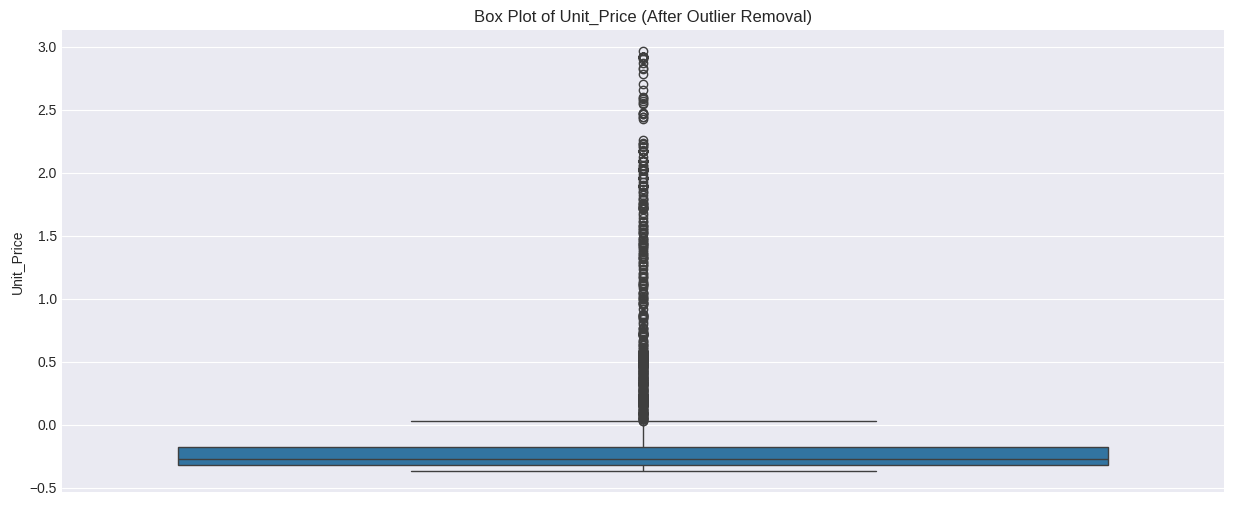

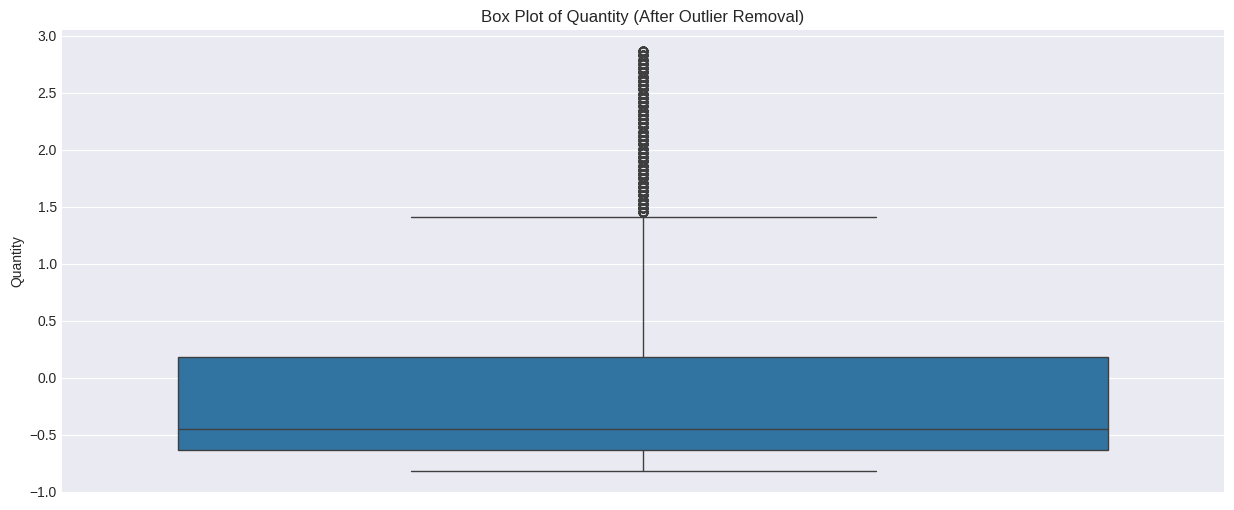

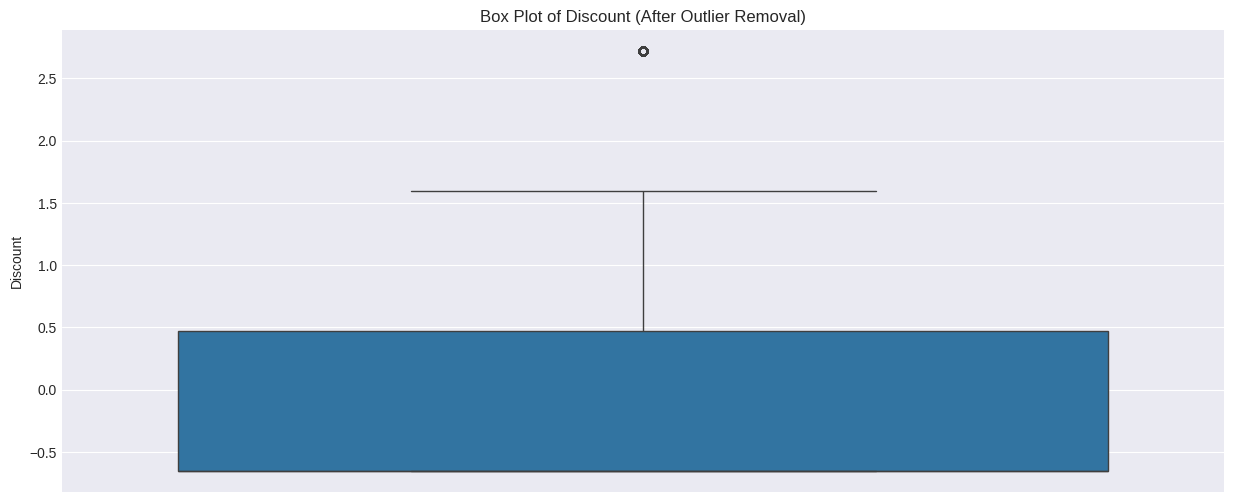

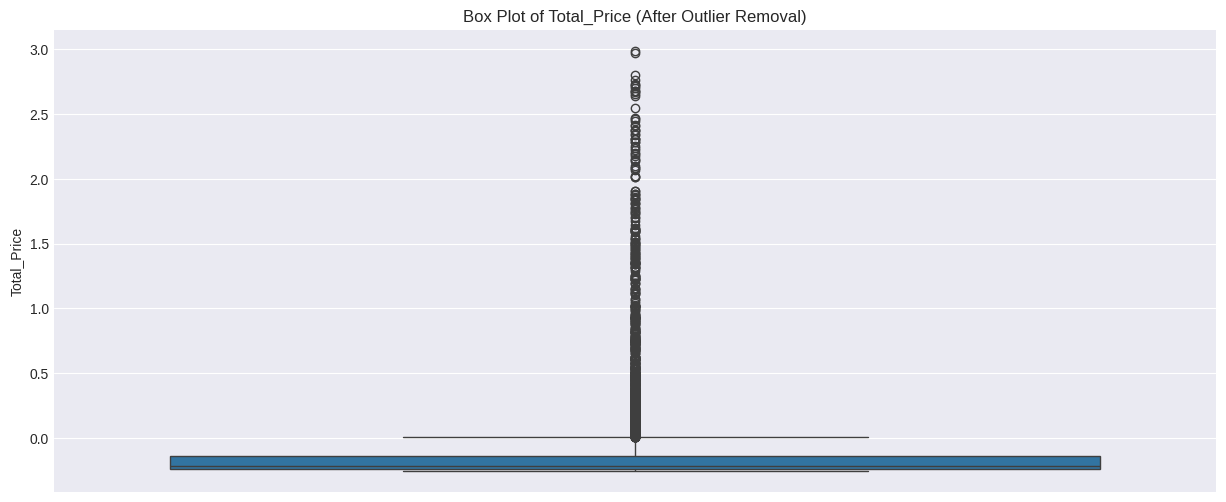

In [ ]:
z_df = df.copy()
z_scores = zscore(z_df[num_features.columns])
outliers = (np.abs(z_scores) > 3).any(axis=1)
df_clean = z_scores[~outliers]

for columns in df_clean:
    plt.figure(4, figsize = (15 , 6))
    sns.boxplot(y=df_clean[columns])
    plt.title(f'Box Plot of {columns} (After Outlier Removal)')
    plt.ylabel(columns)

    plt.show()

Setelah sekian percobaan, saya mengetahui bahwa outlier yang ada memang mungkin terjadi dikarenakan outlier yang ada merupakan data pembelian yang memang "banyak". Banyak dalam artian ini yaitu total penjualan yang tinggi atau pembelian dengan kuantitas banyak.

In [ ]:
df2 = df.copy()
le_category = LabelEncoder()
le_region = LabelEncoder()
df2['Category_encoded'] = le_category.fit_transform(df2['Category'])
df2['Region_encoded'] = le_region.fit_transform(df2['Region'])
print(df2[['Category', 'Category_encoded', 'Region', 'Region_encoded']].head(15))

               Category  Category_encoded              Region  Region_encoded
0                 Water                 3   Baden-Württemberg               0
1                 Water                 3   Baden-Württemberg               0
2           Soft Drinks                 2   Baden-Württemberg               0
3                Juices                 1   Baden-Württemberg               0
4                 Water                 3   Baden-Württemberg               0
5   Alcoholic Beverages                 0  Schleswig-Holstein              14
6                Juices                 1             Hamburg               5
7                 Water                 3             Hamburg               5
8                 Water                 3             Hamburg               5
9                 Water                 3             Hamburg               5
10          Soft Drinks                 2              Bayern               1
11               Juices                 1              Bayern   

Pada Data ini saya akan melakukan Standardisasi terhadap Unit_Price, Quantity, Discount, dan Total_Price.

In [ ]:
scaler = StandardScaler()
num_features = df.select_dtypes(include=['int64', 'float64'])
df_scaled = scaler.fit_transform(df[num_features.columns])
columns_name = num_features.columns
df_scaled = pd.DataFrame(df_scaled, columns=columns_name)
df_scaled = pd.concat([df_scaled, df2.drop(columns=num_features)], axis=1)
df_scaled.head(10)

,Unit_Price,Quantity,Discount,Total_Price,Order_ID,Customer_ID,Customer_Type,Product,Category,Region,Category_encoded,Region_encoded
0,-0.278966,1.114441,1.594961,-0.095355,ORD1,CUS1496,B2B,Vio Wasser,Water,Baden-Württemberg,3,0
1,-0.285759,2.491690,1.594961,-0.000378,ORD1,CUS1496,B2B,Evian,Water,Baden-Württemberg,3,0
2,-0.312252,1.858900,0.470720,-0.091409,ORD1,CUS1496,B2B,Sprite,Soft Drinks,Baden-Württemberg,2,0
3,-0.172993,1.337778,1.594961,0.089445,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,Baden-Württemberg,1,0
4,-0.332632,0.444427,1.594961,-0.199592,ORD1,CUS1496,B2B,Gerolsteiner,Water,Baden-Württemberg,3,0
5,0.225764,-0.783931,-0.653521,-0.218152,ORD2,CUS2847,B2C,Sauvignon Blanc,Alcoholic Beverages,Schleswig-Holstein,0,14
6,-0.246359,0.779434,1.594961,-0.084162,ORD3,CUS1806,B2B,Tomato Juice,Juices,Hamburg,1,5
7,-0.362522,-0.374478,0.470720,-0.244060,ORD3,CUS1806,B2B,Vittel,Water,Hamburg,3,5
8,-0.309535,2.566136,1.594961,-0.053060,ORD3,CUS1806,B2B,San Pellegrino,Water,Hamburg,3,5
9,-0.297987,-0.746708,0.470720,-0.246838,ORD3,CUS1806,B2B,Evian,Water,Hamburg,3,5


In [ ]:
for feature in num_features:
    df[f"{feature}_bin_width"] = pd.cut(df[feature], bins=4, labels=["Low", "Medium", "High", "Very High"])

for feature in num_features:
    df[f"{feature}_bin_freq"] = pd.qcut(df[feature].rank(method="first"), q=4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")


print(df[[f"{feature}_bin_width" for feature in num_features] +
         [f"{feature}_bin_freq" for feature in num_features]].head())

  Unit_Price_bin_width Quantity_bin_width Discount_bin_width  \
0                  Low               High               High   
1                  Low          Very High               High   
2                  Low               High             Medium   
3                  Low               High               High   
4                  Low             Medium               High   

  Total_Price_bin_width Unit_Price_bin_freq Quantity_bin_freq  \
0                   Low                  Q2                Q4   
1                   Low                  Q2                Q4   
2                   Low                  Q2                Q4   
3                   Low                  Q4                Q4   
4                   Low                  Q1                Q4   

  Discount_bin_freq Total_Price_bin_freq  
0                Q4                   Q4  
1                Q4                   Q4  
2                Q3                   Q4  
3                Q4                   Q4  
4        

In [ ]:
for feature in ["Unit_Price", "Quantity", "Discount", "Total_Price"]:
    print(df[f"{feature}_bin_width"].value_counts())
    print(df[f"{feature}_bin_freq"].value_counts())

Unit_Price_bin_width
Low          9435
Medium        429
Very High      95
High           41
Name: count, dtype: int64
Unit_Price_bin_freq
Q1    2500
Q2    2500
Q3    2500
Q4    2500
Name: count, dtype: int64
Quantity_bin_width
Low          7368
Very High     891
Medium        890
High          851
Name: count, dtype: int64
Quantity_bin_freq
Q1    2500
Q2    2500
Q3    2500
Q4    2500
Name: count, dtype: int64
Discount_bin_width
Low          6507
Medium       1592
High         1482
Very High     419
Name: count, dtype: int64
Discount_bin_freq
Q1    2500
Q2    2500
Q3    2500
Q4    2500
Name: count, dtype: int64
Total_Price_bin_width
Low          9915
Medium         59
High           17
Very High       9
Name: count, dtype: int64
Total_Price_bin_freq
Q1    2500
Q2    2500
Q3    2500
Q4    2500
Name: count, dtype: int64




---



In [ ]:
# pca = PCA()
# X_pca = pca.fit_transform(X_scaled)

# plt.figure(figsize=(8,5))
# plt.plot(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
# plt.xlabel("Number of Principal Components")
# plt.ylabel("Cumulative Explained Variance")
# plt.title("Explained Variance by Components")
# plt.show()

In [ ]:
# for i, var in enumerate(pca.explained_variance_ratio_.cumsum()):
#     print(f'PC {i+1}: {var:.2f}% Variance Explained')

# **6. Pembangunan Model Clustering**

## **a. Pembangunan Model Clustering**

Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan. Berikut adalah **rekomendasi** tahapannya.
1. Pilih algoritma clustering yang sesuai.
2. Latih model dengan data menggunakan algoritma tersebut.

In [ ]:
X1 = df[['Unit_Price', 'Total_Price']].values
inertia = []
for n in range(1, 11):
    algorithm = KMeans(
        n_clusters=n,
        init='k-means++',
        n_init=10,
        max_iter=300,
        tol=0.0001,
        random_state=111,
        algorithm='elkan'
    )
    algorithm.fit(X1)
    inertia.append(algorithm.inertia_)

/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:1408: RuntimeWarning: algorithm='elkan' doesn't make sense for a single cluster. Using 'lloyd' instead.
  warnings.warn(


## **b. Evaluasi Model Clustering**

Untuk menentukan jumlah cluster yang optimal dalam model clustering, Anda dapat menggunakan metode Elbow atau Silhouette Score.

Metode ini membantu kita menemukan jumlah cluster yang memberikan pemisahan terbaik antar kelompok data, sehingga model yang dibangun dapat lebih efektif. Berikut adalah **rekomendasi** tahapannya.
1. Gunakan Silhouette Score dan Elbow Method untuk menentukan jumlah cluster optimal.
2. Hitung Silhouette Score sebagai ukuran kualitas cluster.

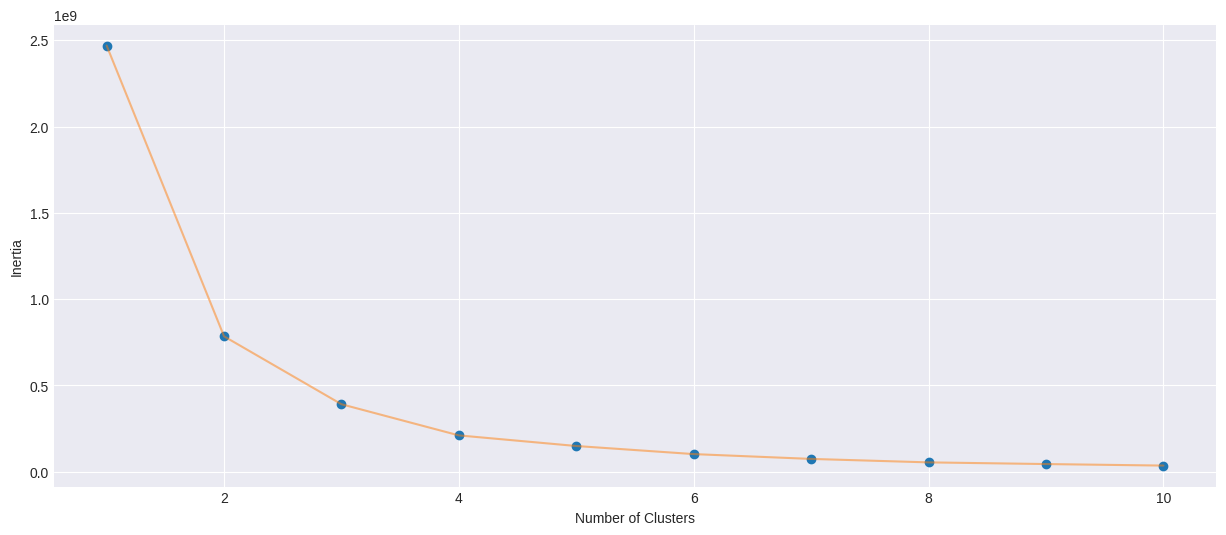

In [ ]:
plt.figure(1 , figsize = (15 ,6))
plt.plot(np.arange(1 , 11) , inertia , 'o')
plt.plot(np.arange(1 , 11) , inertia , '-' , alpha = 0.5)
plt.xlabel('Number of Clusters') , plt.ylabel('Inertia')
plt.show()

In [ ]:
algorithm = (KMeans(n_clusters = 3 ,init='k-means++', n_init = 10 ,max_iter=300,
                        tol=0.0001,  random_state= 111  , algorithm='elkan') )

algorithm.fit(X1)
labels1 = algorithm.labels_
centroids1 = algorithm.cluster_centers_

In [ ]:
h = 0.1
x_min, x_max = X1[:, 0].min() - 1, X1[:, 0].max() + 1
y_min, y_max = X1[:, 1].min() - 1, X1[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = algorithm.predict(np.c_[xx.ravel(), yy.ravel()])

In [ ]:
plt.figure(1 , figsize = (15 , 7) )
plt.clf()
Z = Z.reshape(xx.shape)
plt.imshow(Z , interpolation='nearest',
           extent=(xx.min(), xx.max(), yy.min(), yy.max()),
           cmap = plt.cm.Set3, aspect = 'auto', origin='lower')

plt.scatter( x = df['Unit_Price'] ,y = df['Total_Price'], c = labels1 ,
            s = 200 )
plt.scatter(x = centroids1[: , 0] , y =  centroids1[: , 1] , s = 300 , c = 'red' , alpha = 0.5)
plt.ylabel('Total_Price') , plt.xlabel('Unit_Price')
plt.show()

## **c. Feature Selection (Opsional)**

Silakan lakukan feature selection jika Anda membutuhkan optimasi model clustering. Jika Anda menerapkan proses ini, silakan lakukan pemodelan dan evaluasi kembali menggunakan kolom-kolom hasil feature selection. Terakhir, bandingkan hasil performa model sebelum dan sesudah menerapkan feature selection.

In [ ]:
#Type your code here

## **d. Visualisasi Hasil Clustering**

Setelah model clustering dilatih dan jumlah cluster optimal ditentukan, langkah selanjutnya adalah menampilkan hasil clustering melalui visualisasi.

Berikut adalah **rekomendasi** tahapannya.
1. Tampilkan hasil clustering dalam bentuk visualisasi, seperti grafik scatter plot atau 2D PCA projection.

In [ ]:
#Type your code here

## **e. Analisis dan Interpretasi Hasil Cluster**

### Interpretasi Target

**Tutorial: Melakukan Inverse Transform pada Data Target Setelah Clustering**

Setelah melakukan clustering dengan model **KMeans**, kita perlu mengembalikan data yang telah diubah (normalisasi, standarisasi, atau label encoding) ke bentuk aslinya. Berikut adalah langkah-langkahnya.

---

**1. Tambahkan Hasil Label Cluster ke DataFrame**
Setelah mendapatkan hasil clustering, kita tambahkan label cluster ke dalam DataFrame yang telah dinormalisasi.

```python
df_normalized['Cluster'] = model_kmeans.labels_
```

Lakukan Inverse Transform pada feature yang sudah dilakukan Labelisasi dan Standararisasi. Berikut code untuk melakukannya:
label_encoder.inverse_transform(X_Selected[['Fitur']])

Lalu masukkan ke dalam kolom dataset asli atau membuat dataframe baru
```python
df_normalized['Fitur'] = label_encoder.inverse_transform(df_normalized[['Fitur']])
```
Masukkan Data yang Sudah Di-Inverse ke dalam Dataset Asli atau Buat DataFrame Baru
```python
df_original['Fitur'] = df_normalized['Fitur']
```

In [ ]:
# Type your code here


### Inverse Data Jika Melakukan Normalisasi/Standardisasi

Inverse Transform untuk Data yang Distandarisasi
Jika data numerik telah dinormalisasi menggunakan StandardScaler atau MinMaxScaler, kita bisa mengembalikannya ke skala asli:
```python
df_normalized[['Fitur_Numerik']] = scaler.inverse_transform(df_normalized[['Fitur_Numerik']])
```

In [ ]:
# Type your code here

Setelah melakukan clustering, langkah selanjutnya adalah menganalisis karakteristik dari masing-masing cluster berdasarkan fitur yang tersedia.

Berikut adalah **rekomendasi** tahapannya.
1. Analisis karakteristik tiap cluster berdasarkan fitur yang tersedia (misalnya, distribusi nilai dalam cluster).
2. Berikan interpretasi: Apakah hasil clustering sesuai dengan ekspektasi dan logika bisnis? Apakah ada pola tertentu yang bisa dimanfaatkan?

In [ ]:
# Type your code here

Tulis hasil interpretasinya di sini.
1. Cluster 1:
2. Cluster 2:
3. Cluster 3:

# Contoh interpretasi [TEMPLATE]
# Analisis Karakteristik Cluster dari Model KMeans

Berikut adalah analisis karakteristik untuk setiap cluster yang dihasilkan dari model KMeans.

## Cluster 1:
- **Rata-rata Annual Income (k$):** 48,260  
- **Rata-rata Spending Score (1-100):** 56.48  
- **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan menengah dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang moderat dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka.

## Cluster 2:
- **Rata-rata Annual Income (k$):** 86,540  
- **Rata-rata Spending Score (1-100):** 82.13  
- **Analisis:** Cluster ini menunjukkan pelanggan dengan pendapatan tahunan tinggi dan pengeluaran yang sangat tinggi. Pelanggan di cluster ini merupakan kelompok premium dengan daya beli yang kuat dan cenderung mengeluarkan uang dalam jumlah besar untuk produk atau layanan.

## Cluster 3:
- **Rata-rata Annual Income (k$):** 87,000  
- **Rata-rata Spending Score (1-100):** 18.63  
- **Analisis:** Cluster ini terdiri dari pelanggan dengan pendapatan tahunan yang tinggi tetapi pengeluaran yang rendah. Mereka mungkin memiliki kapasitas finansial yang baik namun tidak terlalu aktif dalam berbelanja. Ini bisa menunjukkan bahwa mereka lebih selektif dalam pengeluaran mereka atau mungkin lebih cenderung untuk menyimpan uang.

# **7. Mengeksport Data**

Simpan hasilnya ke dalam file CSV.